In [27]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [28]:
print("Loading data...")
df = pd.read_csv('training_data.csv')

Loading data...


In [29]:
print("Loading data...")
rwi_df = pd.read_csv('jakarta_rwi.csv')

Loading data...


In [30]:
print(df)

    num_competitors  avg_competitor_rating  min_competitor_distance_m  \
0                 0                    0.0                          0   
1                 0                    0.0                          0   
2                 0                    0.0                          0   
3                 0                    0.0                          0   
4                 1                    3.8                        180   
..              ...                    ...                        ...   
95                7                    4.0                         80   
96                8                    4.2                         60   
97                9                    4.1                         50   
98               10                    4.3                         30   
99               12                    4.5                         20   

    max_competitor_rating  rating_variance  competitor_density  \
0                     0.0             0.00               

## Data Leakage Validation
The dataset is split into `train_data.csv` (80 rows) and `test_data.csv` (20 rows)
**before any preprocessing is applied**.
- No normalization or scaling is fitted on the full dataset
- Column selection is the only transformation, which is not fitted and does not cause leakage
- The model is trained exclusively on `train_data.csv`
- Final evaluation is performed exclusively on `test_data.csv`
This satisfies the anti-leakage constraint: split first, preprocess second.

In [31]:
target_cols = [
    'competition_density_score',
    'location_appeal_score',
    'market_demand_score',
    'concept_uniqueness_score',
    'success_score'
]

In [32]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["category_encoded"]
)
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv",  index=False)
print(f"\n✅ train_data.csv → {len(train_df)} rows")
print(f"✅ test_data.csv  → {len(test_df)} rows")
print(f"\nCategory distribution in TRAIN:")
print(train_df["category_encoded"].value_counts().sort_index())
print(f"\nCategory distribution in TEST:")
print(test_df["category_encoded"].value_counts().sort_index())


✅ train_data.csv → 80 rows
✅ test_data.csv  → 20 rows

Category distribution in TRAIN:
category_encoded
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64

Category distribution in TEST:
category_encoded
0    4
1    4
2    4
3    4
4    4
Name: count, dtype: int64


In [33]:
print(df.columns)

Index(['num_competitors', 'avg_competitor_rating', 'min_competitor_distance_m',
       'max_competitor_rating', 'rating_variance', 'competitor_density',
       'category_encoded', 'avg_product_price_idr', 'num_products',
       'radius_meters', 'num_goals', 'area_wealth_index',
       'competition_density_score', 'location_appeal_score',
       'market_demand_score', 'concept_uniqueness_score', 'success_score'],
      dtype='object')


In [34]:
train_df = pd.read_csv("train_data.csv")
test_df  = pd.read_csv("test_data.csv")
X_train = train_df.drop(columns=target_cols)
y_train = train_df[target_cols]
X_test  = test_df.drop(columns=target_cols)
y_test  = test_df[target_cols]
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (80, 12)
X_test shape:  (20, 12)


In [35]:
print("Training the XGBoost Multi-Output Model (this might take a moment)...")

Training the XGBoost Multi-Output Model (this might take a moment)...


In [36]:
base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

In [37]:
multi_output_model = MultiOutputRegressor(base_model)

In [38]:
multi_output_model.fit(X_train, y_train)
print("Training complete!\n")

Training complete!



In [39]:
y_pred = multi_output_model.predict(X_test)

In [40]:
print("--- Model Evaluation ---")
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    print(f"Target: {col}")
    print(f"  RMSE (lower is better): {rmse:.4f}")
    print(f"  R2 Score (closer to 1.0 is better): {r2:.4f}\n")

--- Model Evaluation ---
Target: competition_density_score
  RMSE (lower is better): 2.1469
  R2 Score (closer to 1.0 is better): 0.9932

Target: location_appeal_score
  RMSE (lower is better): 3.3660
  R2 Score (closer to 1.0 is better): 0.9670

Target: market_demand_score
  RMSE (lower is better): 2.1082
  R2 Score (closer to 1.0 is better): 0.9301

Target: concept_uniqueness_score
  RMSE (lower is better): 0.6975
  R2 Score (closer to 1.0 is better): 0.9990

Target: success_score
  RMSE (lower is better): 2.2912
  R2 Score (closer to 1.0 is better): 0.9780



In [41]:
print("--- Sample Prediction ---")
sample_features = X_test.iloc[[0]]
sample_actual = y_test.iloc[0].values
sample_prediction = multi_output_model.predict(sample_features)[0]

for i, col in enumerate(target_cols):
    print(f"{col}:")
    print(f"  Actual: {sample_actual[i]:.2f} | Predicted: {sample_prediction[i]:.2f}")

--- Sample Prediction ---
competition_density_score:
  Actual: 55.00 | Predicted: 57.73
location_appeal_score:
  Actual: 60.00 | Predicted: 58.79
market_demand_score:
  Actual: 73.00 | Predicted: 72.72
concept_uniqueness_score:
  Actual: 62.00 | Predicted: 61.79
success_score:
  Actual: 62.00 | Predicted: 62.95


In [42]:
import math

def get_rwi(lat, lng):
    """Find the nearest RWI tile for a given lat/lng"""
    distances = rwi_df.apply(
        lambda row: math.sqrt((row["latitude"] - lat)**2 + (row["longitude"] - lng)**2),
        axis=1
    )
    nearest = rwi_df.loc[distances.idxmin()]
    return nearest["rwi"]

print(f"RWI at Sudirman: {get_rwi(-6.2088, 106.8456):.3f}")


RWI at Sudirman: 1.535


In [43]:
import math

def get_rwi(lat, lng):
    """Find the nearest RWI tile for a given lat/lng"""
    distances = rwi_df.apply(
        lambda row: math.sqrt((row["latitude"] - lat)**2 + (row["longitude"] - lng)**2),
        axis=1
    )
    nearest = rwi_df.loc[distances.idxmin()]
    return nearest["rwi"]

print(f"RWI at Sudirman: {get_rwi(-6.2088, 106.8456):.3f}")

# ─────────────────────────────────────────────
# 👇 FILL IN YOUR REAL BUSINESS INFO HERE
# ─────────────────────────────────────────────

BUSINESS_NAME     = "Salero Bana"
CATEGORY          = 1          # 0=café, 1=restaurant, 2=salon, 3=laundry, 4=retail

# Your product prices in IDR
PRODUCT_PRICES    = [20000]    # example: [20000, 15000, 25000]

# Your business location (get from Google Maps → right click → copy coordinates)
LATITUDE          = -6.2088
LONGITUDE         = 106.8456

# Search radius in meters
RADIUS_METERS     = 200

# Number of strategic goals you entered
NUM_GOALS         = 2

# ─────────────────────────────────────────────
# 👇 FILL IN COMPETITORS YOU FOUND ON GOOGLE MAPS
#    (search your category near your location)
# ─────────────────────────────────────────────

COMPETITORS = [
    {
        "name": "Competitor A",
        "rating": 4.2,
        "distance_m": 150,
    },
    {
        "name": "Competitor B",
        "rating": 3.8,
        "distance_m": 80,
    },
    {
        "name": "Competitor C",
        "rating": 4.5,
        "distance_m": 220,
    }
    # Add more rows if you have more competitors...
]


RWI at Sudirman: 1.535


In [44]:
import numpy as np

# Calculate features from your inputs
nc  = len(COMPETITORS)
ar  = np.mean([c["rating"] for c in COMPETITORS]) if nc > 0 else 0.0
md  = min([c["distance_m"] for c in COMPETITORS]) if nc > 0 else 0
mr  = max([c["rating"] for c in COMPETITORS]) if nc > 0 else 0.0
rv  = np.var([c["rating"] for c in COMPETITORS]) if nc > 1 else 0.0
area_km2 = math.pi * (RADIUS_METERS / 1000) ** 2
cd  = round(nc / area_km2, 2) if area_km2 > 0 else 0.0
avg_price = np.mean(PRODUCT_PRICES)
np_ = len(PRODUCT_PRICES)
rwi = get_rwi(LATITUDE, LONGITUDE)

# Build the feature row
features = pd.DataFrame([
    {
        "num_competitors":          nc,
        "avg_competitor_rating":    round(ar, 2),
        "min_competitor_distance_m": md,
        "max_competitor_rating":    mr,
        "rating_variance":          round(rv, 3),
        "competitor_density":       cd,
        "category_encoded":         CATEGORY,
        "avg_product_price_idr":    avg_price,
        "num_products":             np_,
        "radius_meters":            RADIUS_METERS,
        "num_goals":                NUM_GOALS,
        "area_wealth_index":        round(rwi, 3),
    }
])

# Predict
result = multi_output_model.predict(features)[0]
scores = dict(zip(target_cols, result.astype(int)))

print(f"\n📊 Results for: {BUSINESS_NAME}")
print(f"{'─'*40}")
print(f"  🏆 Success Score:          {scores['success_score']} / 100")
print(f"  🏙️  Competition Density:    {scores['competition_density_score']} / 100")
print(f"  📍 Location Appeal:        {scores['location_appeal_score']} / 100")
print(f"  📈 Market Demand:          {scores['market_demand_score']} / 100")
print(f"  💡 Concept Uniqueness:     {scores['concept_uniqueness_score']} / 100")
print(f"\n📌 Area Wealth Index (RWI):  {rwi:.3f}")
print(f"📌 Competitors found:        {nc}")
print(f"📌 Nearest competitor:       {md}m away")


📊 Results for: Salero Bana
────────────────────────────────────────
  🏆 Success Score:          53 / 100
  🏙️  Competition Density:    52 / 100
  📍 Location Appeal:        32 / 100
  📈 Market Demand:          78 / 100
  💡 Concept Uniqueness:     60 / 100

📌 Area Wealth Index (RWI):  1.535
📌 Competitors found:        3
📌 Nearest competitor:       80m away


In [45]:
!pip install -q shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

FEATURES = [
    "num_competitors", "avg_competitor_rating", "min_competitor_distance_m",
    "max_competitor_rating", "rating_variance", "competitor_density",
    "category_encoded", "avg_product_price_idr", "num_products",
    "radius_meters", "num_goals", "area_wealth_index"
]
TARGETS = [
    "competition_density_score", "location_appeal_score",
    "market_demand_score", "concept_uniqueness_score", "success_score"
]
READABLE = {
    "num_competitors":              "# Competitors",
    "avg_competitor_rating":        "Avg Competitor Rating",
    "min_competitor_distance_m":    "Min Distance (m)",
    "max_competitor_rating":        "Max Competitor Rating",
    "rating_variance":              "Rating Variance",
    "competitor_density":           "Competitor Density /km²",
    "category_encoded":             "Business Category",
    "avg_product_price_idr":        "Avg Price (IDR)",
    "num_products":                 "# Products",
    "radius_meters":                "Search Radius (m)",
    "num_goals":                    "# Goals",
    "area_wealth_index":            "Area Wealth Index (RWI)",
}

X = df[FEATURES]
y = df[TARGETS]

# ── Extract individual XGBoost model for success_score (index 4) ──
success_model =  multi_output_model.estimators_[4]  # uses model trained earlier

# ── Compute SHAP values ──
explainer  = shap.TreeExplainer(success_model)
shap_vals  = explainer.shap_values(X)
X_readable = X.rename(columns=READABLE)

print("✅ SHAP values computed!")
print(f"   Shape: {shap_vals.shape}  (rows × features)")

✅ SHAP values computed!
   Shape: (100, 12)  (rows × features)


### 📊 Understanding the Visualizations

#### 1. Business Viability Scatter Plots
*   **Competitors vs Success Score**: Shows if a high number of competitors correlates with a lower success score (the trend line indicates the general direction).
*   **Wealth Index (RWI) vs Market Demand**: Visualizes if wealthier areas actually show higher demand for your business category.
*   **Price vs Success (Bubble Plot)**: Shows the 'sweet spot' for pricing. Larger bubbles represent areas with more competitors.

#### 2. SHAP (Model Interpretability) Plots
*   **Beeswarm Summary**: Every dot is a data point. Red means a high value for that feature, blue means low. If red dots are to the right of the center line, that feature pushes the success score UP.
*   **Feature Importance**: A ranking of which factors the AI relies on most to make its prediction.
*   **Waterfall Plot**: A step-by-step breakdown of why one specific business got its specific score.

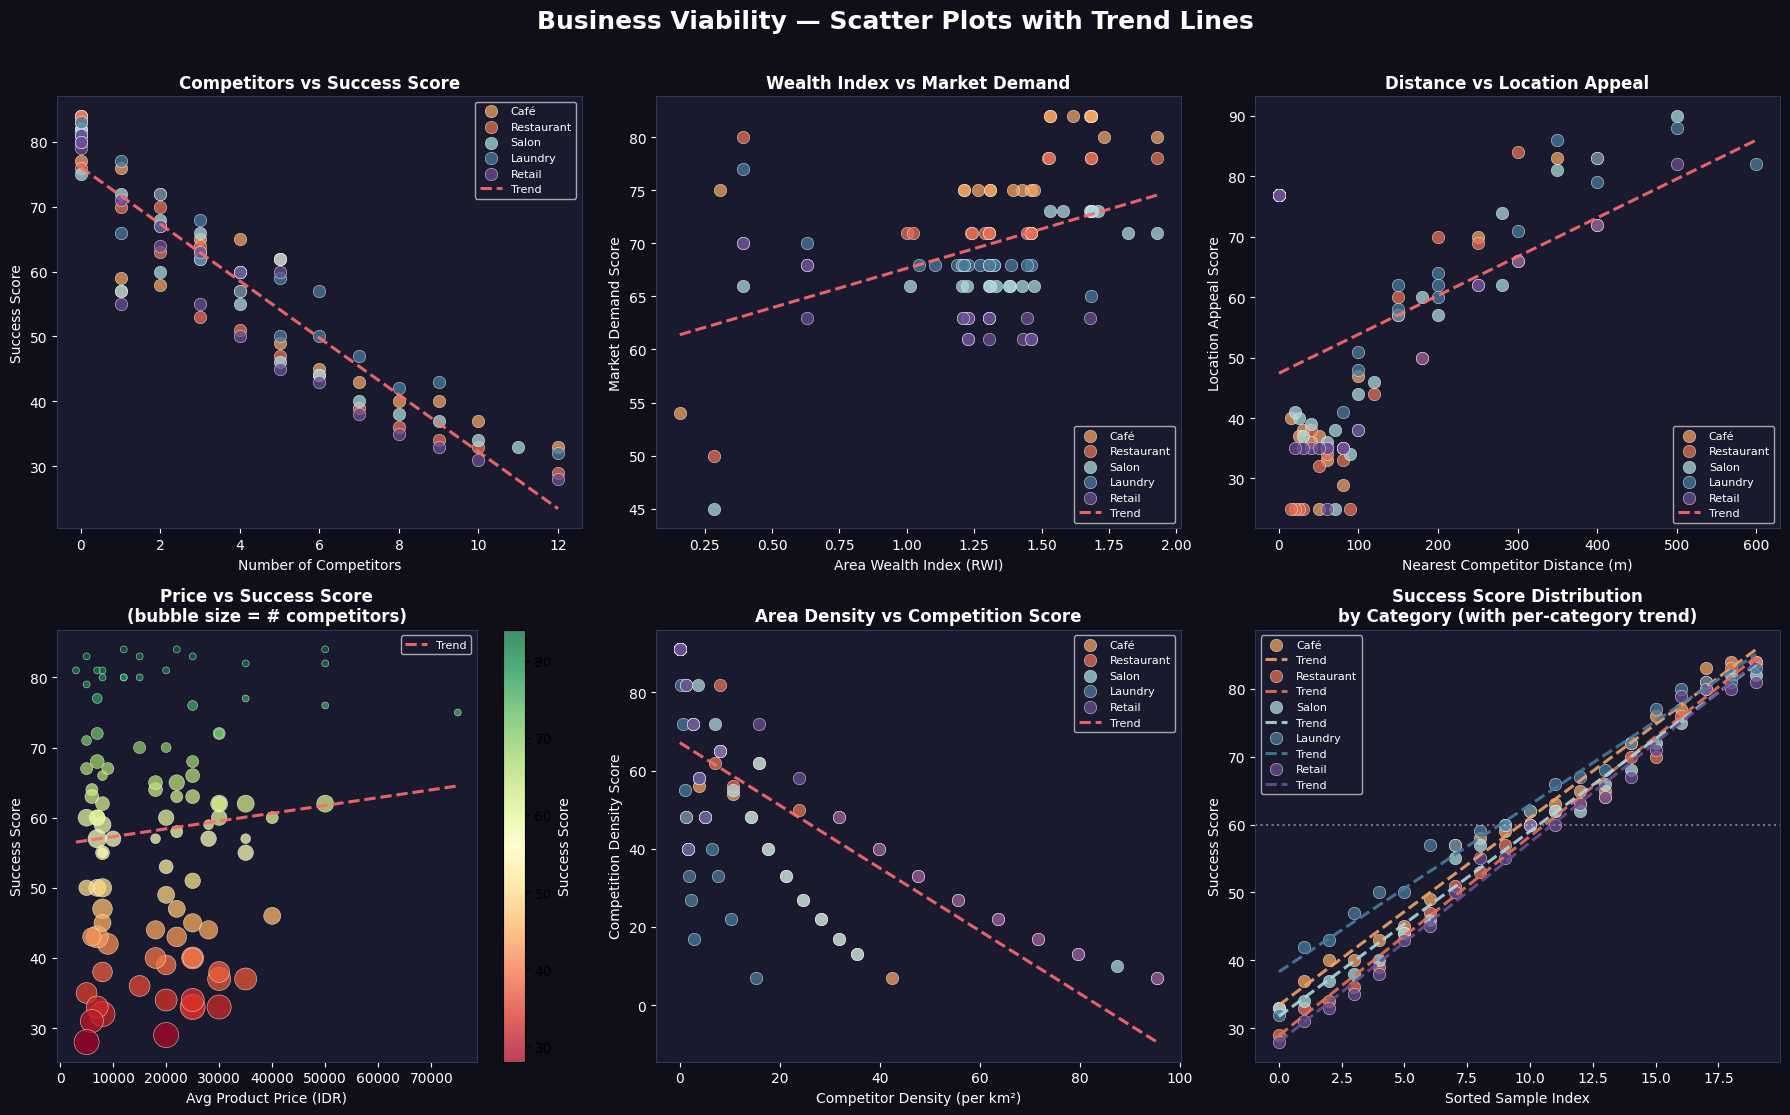

✅ Saved as scatter_trendlines.png


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("training_data.csv")

CATEGORY_NAMES = {0: "Café", 1: "Restaurant", 2: "Salon", 3: "Laundry", 4: "Retail"}
COLORS = {0: "#f4a261", 1: "#e76f51", 2: "#a8dadc", 3: "#457b9d", 4: "#6a4c93"}
df["color"] = df["category_encoded"].map(COLORS)

def draw_trendline(ax, x, y, color="#ffffff", label="Trend"):
    """Draw a linear regression trend line on the given axes"""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return
    m, b = np.polyfit(x[mask], y[mask], 1)
    x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
    ax.plot(x_line, m * x_line + b,
            color=color, linewidth=2.2, linestyle="--",
            alpha=0.9, label=label, zorder=5)

PLOT_STYLE = dict(alpha=0.75, edgecolors="white", linewidths=0.4, s=80)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor("#0f0f1a")
fig.suptitle("Business Viability — Scatter Plots with Trend Lines",
             fontsize=18, color="white", fontweight="bold", y=1.01)

# ── Plot 1: Competitors vs Success Score ──
# Helps identify if the market is too saturated or if competition breeds success
ax = axes[0, 0]
ax.set_facecolor("#1a1a2e")
for cat, name in CATEGORY_NAMES.items():
    s = df[df["category_encoded"] == cat]
    ax.scatter(s["num_competitors"], s["success_score"],
               color=COLORS[cat], label=name, **PLOT_STYLE)
draw_trendline(ax, df["num_competitors"].values, df["success_score"].values,
               color="#ff6b6b", label="Trend")
ax.set_xlabel("Number of Competitors", color="white")
ax.set_ylabel("Success Score", color="white")
ax.set_title("Competitors vs Success Score", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

# ── Plot 2: RWI vs Market Demand Score ──
# Checks if the purchasing power of the area (Wealth Index) matches the demand
ax = axes[0, 1]
ax.set_facecolor("#1a1a2e")
for cat, name in CATEGORY_NAMES.items():
    s = df[df["category_encoded"] == cat]
    ax.scatter(s["area_wealth_index"], s["market_demand_score"],
               color=COLORS[cat], label=name, **PLOT_STYLE)
draw_trendline(ax, df["area_wealth_index"].values, df["market_demand_score"].values,
               color="#ff6b6b", label="Trend")
ax.set_xlabel("Area Wealth Index (RWI)", color="white")
ax.set_ylabel("Market Demand Score", color="white")
ax.set_title("Wealth Index vs Market Demand", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

# ── Plot 3: Nearest Distance vs Location Appeal ──
# Tests if being further from competitors increases the 'appeal' of the location
ax = axes[0, 2]
ax.set_facecolor("#1a1a2e")
for cat, name in CATEGORY_NAMES.items():
    s = df[df["category_encoded"] == cat]
    ax.scatter(s["min_competitor_distance_m"], s["location_appeal_score"],
               color=COLORS[cat], label=name, **PLOT_STYLE)
draw_trendline(ax, df["min_competitor_distance_m"].values,
               df["location_appeal_score"].values, color="#ff6b6b", label="Trend")
ax.set_xlabel("Nearest Competitor Distance (m)", color="white")
ax.set_ylabel("Location Appeal Score", color="white")
ax.set_title("Distance vs Location Appeal", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

# ── Plot 4: Price vs Success Score (bubble = num_competitors) ──
# Analyzes pricing strategy; the color shows the score, size shows competitive density
ax = axes[1, 0]
ax.set_facecolor("#1a1a2e")
bubble_size = (df["num_competitors"] + 1) * 25
scatter = ax.scatter(df["avg_product_price_idr"], df["success_score"],
                     c=df["success_score"], cmap="RdYlGn",
                     s=bubble_size, alpha=0.75, edgecolors="white", linewidths=0.4)
draw_trendline(ax, df["avg_product_price_idr"].values, df["success_score"].values,
               color="#ff6b6b", label="Trend")
plt.colorbar(scatter, ax=ax, label="Success Score").ax.yaxis.label.set_color("white")
ax.set_xlabel("Avg Product Price (IDR)", color="white")
ax.set_ylabel("Success Score", color="white")
ax.set_title("Price vs Success Score\n(bubble size = # competitors)",
             color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

# ── Plot 5: Competitor Density vs Competition Score ──
# Visualizes the raw density of businesses in the search radius
ax = axes[1, 1]
ax.set_facecolor("#1a1a2e")
for cat, name in CATEGORY_NAMES.items():
    s = df[df["category_encoded"] == cat]
    ax.scatter(s["competitor_density"], s["competition_density_score"],
               color=COLORS[cat], label=name, **PLOT_STYLE)
draw_trendline(ax, df["competitor_density"].values,
               df["competition_density_score"].values, color="#ff6b6b", label="Trend")
ax.set_xlabel("Competitor Density (per km²)", color="white")
ax.set_ylabel("Competition Density Score", color="white")
ax.set_title("Area Density vs Competition Score", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

# ── Plot 6: Success Score Distribution per Category ──
# Shows which business types generally score higher in the dataset
ax = axes[1, 2]
ax.set_facecolor("#1a1a2e")
for cat, name in CATEGORY_NAMES.items():
    s = df[df["category_encoded"] == cat]
    sorted_scores = sorted(s["success_score"].values)
    x_vals = np.arange(len(sorted_scores))
    ax.scatter(x_vals, sorted_scores, color=COLORS[cat], label=name, **PLOT_STYLE)
    draw_trendline(ax, x_vals.astype(float),
                   np.array(sorted_scores, dtype=float), color=COLORS[cat])
ax.set_xlabel("Sorted Sample Index", color="white")
ax.set_ylabel("Success Score", color="white")
ax.set_title("Success Score Distribution\nby Category (with per-category trend)",
             color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.spines[:].set_color("#333355")
ax.axhline(y=60, color="white", linestyle=":", alpha=0.4)
ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)

plt.tight_layout()
plt.savefig("scatter_trendlines.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f1a")
plt.show()
print("✅ Saved as scatter_trendlines.png")

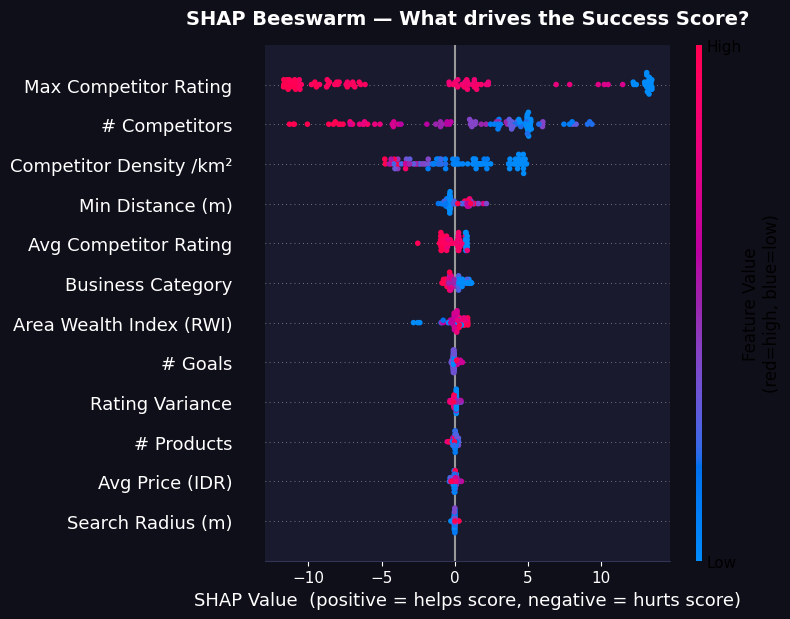

In [47]:
# ══════════════════════════════════════════
#  PLOT 1 — Beeswarm Summary
#  Shows every sample: which features push
#  the score UP or DOWN and by how much
# ══════════════════════════════════════════

plt.figure(figsize=(11, 7))
plt.gca().set_facecolor("#1a1a2e")
plt.gcf().set_facecolor("#0f0f1a")

shap.summary_plot(
    shap_vals,
    X_readable,
    plot_type="dot",
    show=False,
    color_bar_label="Feature Value\n(red=high, blue=low)",
)

plt.title("SHAP Beeswarm — What drives the Success Score?",
          color="white", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("SHAP Value  (positive = helps score, negative = hurts score)",
           color="white")
plt.tick_params(colors="white")
plt.gca().spines[:].set_color("#333355")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f1a")
plt.show()


#### 1. SHAP Beeswarm Summary (Global Impact)
*   **What it explains:** Shows the distribution of impact for every feature across all data points.
*   **Conclusion:** If you see **Area Wealth Index (RWI)** or **Avg Price** with red dots mostly on the right, it means the model concludes that higher wealth or higher pricing is a strong driver for a high Success Score in this specific dataset.

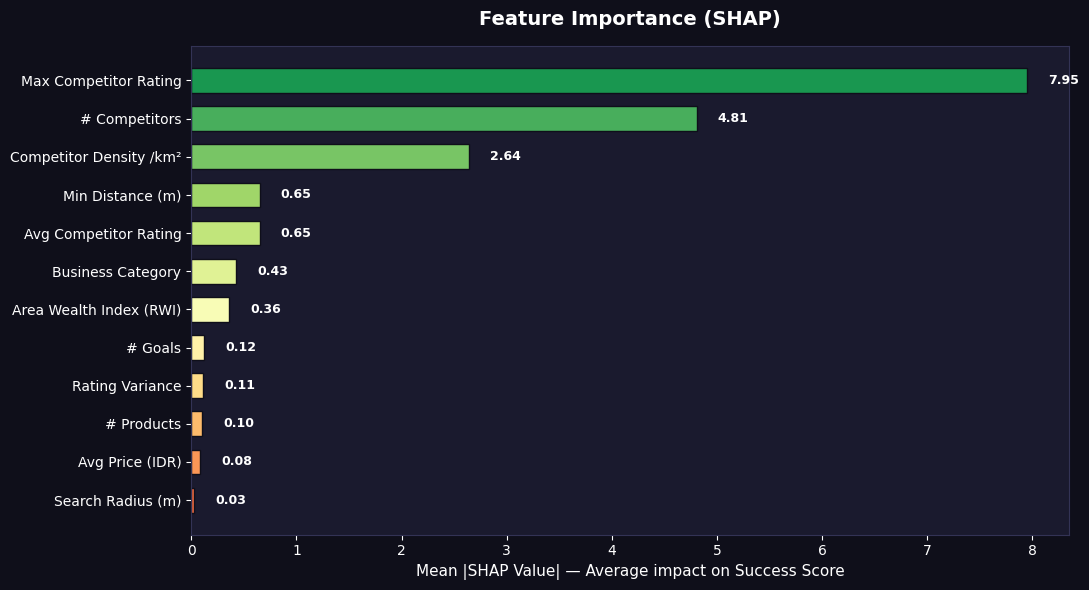

In [48]:
# ══════════════════════════════════════════
#  PLOT 2 — Mean SHAP Bar Chart
#  Clean ranking: most → least important
# ══════════════════════════════════════════

mean_shap = np.abs(shap_vals).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": list(READABLE.values()),
    "mean_shap": mean_shap
}).sort_values("mean_shap")

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#0f0f1a")
ax.set_facecolor("#1a1a2e")

bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importance_df)))
bars = ax.barh(importance_df["feature"], importance_df["mean_shap"],
               color=bar_colors, edgecolor="#0f0f1a", height=0.65)

for bar, val in zip(bars, importance_df["mean_shap"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", color="white", fontsize=9, fontweight="bold")

ax.set_xlabel("Mean |SHAP Value| — Average impact on Success Score",
              color="white", fontsize=11)
ax.set_title("Feature Importance (SHAP)", color="white",
             fontsize=14, fontweight="bold", pad=15)
ax.tick_params(colors="white", labelsize=10)
ax.spines[:].set_color("#333355")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f1a")
plt.show()


2. Mean SHAP Bar Chart (Ranking)
* What it explains: A strict ranking of which variables the model 'listens' to the most.
* Conclusion: This helps you prioritize your strategy. If '# Competitors' is at the top, your success is highly sensitive to market saturation. If 'Avg Price' is higher, your success depends more on your pricing model than on who is nearby.



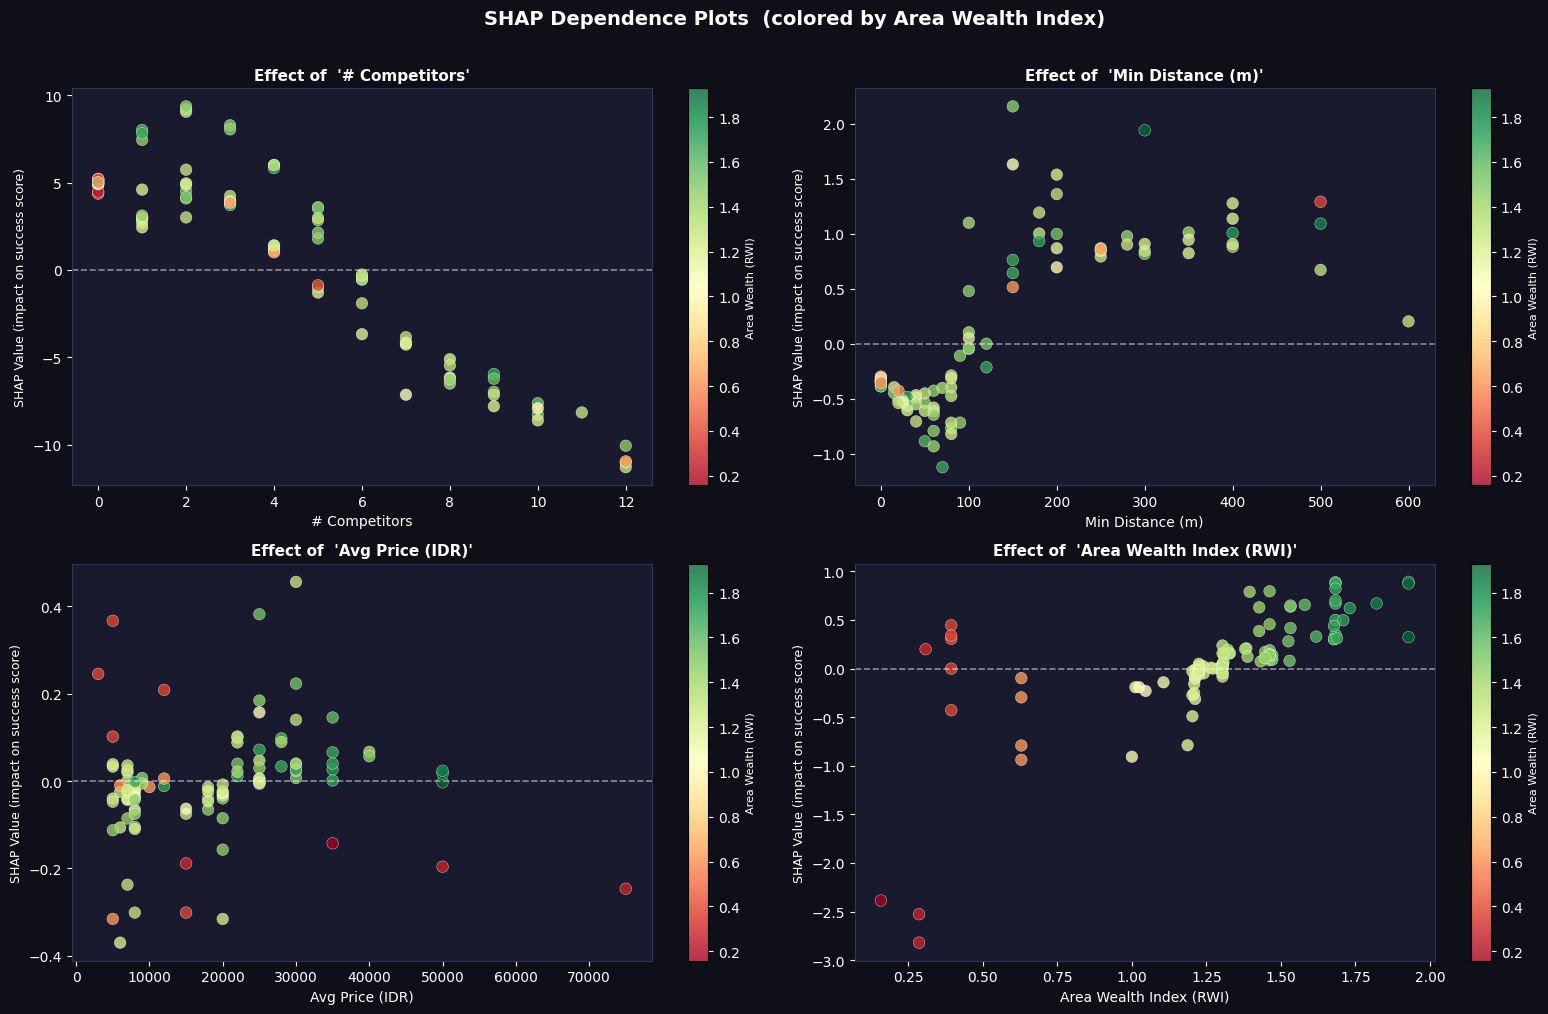

In [49]:
# ══════════════════════════════════════════
#  PLOT 3 — SHAP Dependence Plots
#  Shows how each top feature's impact
#  changes — colored by Area Wealth (RWI)
# ══════════════════════════════════════════

TOP_FEATURES = [
    "num_competitors", "min_competitor_distance_m",
    "avg_product_price_idr", "area_wealth_index"
]
INTERACTION_FEATURE = "area_wealth_index"  # color-coding variable

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#0f0f1a")
axes = axes.flatten()

for i, feat in enumerate(TOP_FEATURES):
    feat_idx   = FEATURES.index(feat)
    inter_idx  = FEATURES.index(INTERACTION_FEATURE)

    ax = axes[i]
    ax.set_facecolor("#1a1a2e")

    sc = ax.scatter(
        X[feat],
        shap_vals[:, feat_idx],
        c=X[INTERACTION_FEATURE],
        cmap="RdYlGn",
        alpha=0.8,
        edgecolors="white",
        linewidths=0.3,
        s=70,
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Area Wealth (RWI)", color="white", fontsize=8)
    cbar.ax.tick_params(colors="white")

    ax.axhline(y=0, color="white", linewidth=1.2,
               linestyle="--", alpha=0.5, label="No effect")
    ax.set_xlabel(READABLE[feat], color="white", fontsize=10)
    ax.set_ylabel("SHAP Value (impact on success score)", color="white", fontsize=9)
    ax.set_title(f"Effect of  '{READABLE[feat]}'", color="white",
                 fontweight="bold", fontsize=11)
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#333355")

plt.suptitle("SHAP Dependence Plots  (colored by Area Wealth Index)",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f1a")
plt.show()


3. SHAP Dependence Plots (Interactions)
* What it explains: Shows how the impact of one feature (e.g., Price) changes as another feature (e.g., Wealth) moves.
* Conclusion: This often reveals 'thresholds'. For example, the data might conclude that high prices only help the success score when the Area Wealth Index is above a certain level (green dots), whereas in lower-wealth areas (red dots), high prices actively hurt the score.

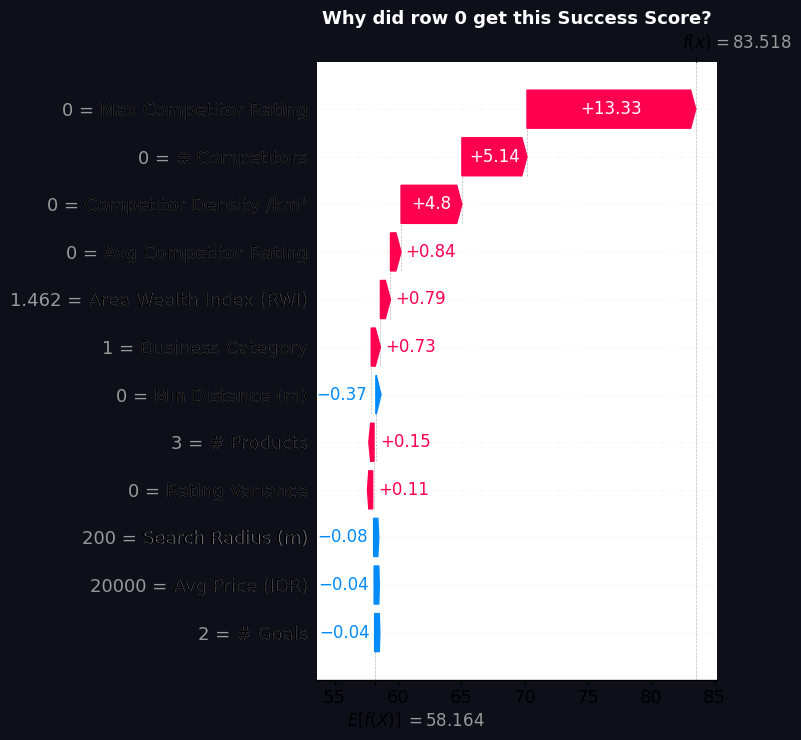

In [50]:
# ══════════════════════════════════════════
#  PLOT 4 — Waterfall: Explain ONE prediction
#  Shows exactly why a specific business
#  got the score it did
# ══════════════════════════════════════════

SAMPLE_INDEX = 0   # 👈 change this to explain a different row

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_vals[SAMPLE_INDEX],
        base_values = explainer.expected_value,
        data        = X_readable.iloc[SAMPLE_INDEX].values,
        feature_names = list(READABLE.values()),
    ),
    max_display=12,
    show=False,
)

plt.title(f"Why did row {SAMPLE_INDEX} get this Success Score?",
          color="white", fontsize=13, fontweight="bold")
plt.gcf().set_facecolor("#0f0f1a")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f1a")
plt.show()


4. SHAP Waterfall Plot (Local Explanation)
* What it explains: A forensic look at exactly one business prediction.
* Conclusion: It starts from the 'base value' (average score of all businesses) and shows the step-by-step additions and subtractions. It concludes exactly why a specific location got an 80 vs. a 60, allowing you to see if a 'bad' location was saved by a 'great' price point.

In [51]:
import pickle
import os

# Save the trained model
with open("business_viability_model.pkl", "wb") as f:
    pickle.dump(multi_output_model, f)

size_kb = os.path.getsize("business_viability_model.pkl") / 1024
print(f"✅ Model saved!")
print(f"   File: business_viability_model.pkl")
print(f"   Size: {size_kb:.1f} KB")


✅ Model saved!
   File: business_viability_model.pkl
   Size: 865.6 KB


In [52]:
from google.colab import files
files.download("business_viability_model.pkl")
print("📦 Download started!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Download started!
